<a href="https://colab.research.google.com/github/Abhinav-bb-09/Customer-Return-Predictor/blob/main/ConsAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

df = pd.read_excel("ice_cream.xlsx")
df.rename(columns={'adv.exp': 'adv_exp'}, inplace=True)
df.head()

,rev,mktshare,price,adv_exp,year,quarter
0,2.884073,0.378149,9.794362,0.388938,1986,1
1,7.711758,0.862744,9.603961,1.071047,1986,2
2,7.851848,0.863849,8.940490,1.100496,1986,3
3,7.153972,0.868125,8.788147,0.968955,1986,4
4,7.597716,0.916656,9.405365,1.441370,1987,1


In [2]:
# Calculate specific summary statistics for all columns
summary_stats = df.agg(['mean', 'median', 'max', 'min', 'std'])
display(summary_stats)

,rev,mktshare,price,adv_exp,year,quarter
mean,6.007194,0.671476,9.254790,0.706348,2001.000000,2.50000
median,6.508860,0.748500,9.314966,0.659229,2001.000000,2.50000
max,9.851349,0.932187,10.952698,1.443329,2016.000000,4.00000
min,0.096809,0.012590,7.775987,0.005449,1986.000000,1.00000
std,2.266747,0.241984,0.710572,0.388124,8.980557,1.12257


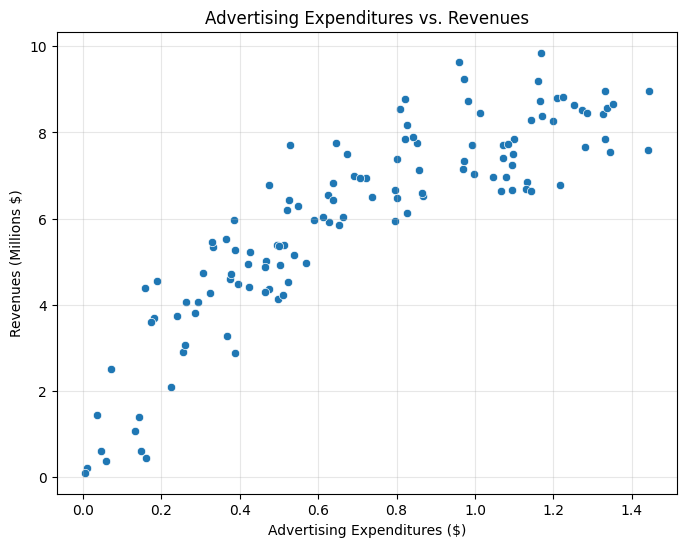

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='adv_exp', y='rev')
plt.title('Advertising Expenditures vs. Revenues')
plt.xlabel('Advertising Expenditures ($)')
plt.ylabel('Revenues (Millions $)')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Fit the regression model
model_1 = smf.ols('rev ~ adv_exp', data=df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                    rev   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     376.7
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           4.14e-39
Time:                        20:03:30   Log-Likelihood:                -189.63
No. Observations:                 124   AIC:                             383.3
Df Residuals:                     122   BIC:                             388.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4219      0.211     11.501      0.0

In [6]:
# Fit the multiple regression model
model_2 = smf.ols('rev ~ adv_exp + price', data=df).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                    rev   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     200.7
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           3.67e-39
Time:                        20:03:54   Log-Likelihood:                -186.23
No. Observations:                 124   AIC:                             378.5
Df Residuals:                     121   BIC:                             386.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.9212      1.735      3.989      0.0

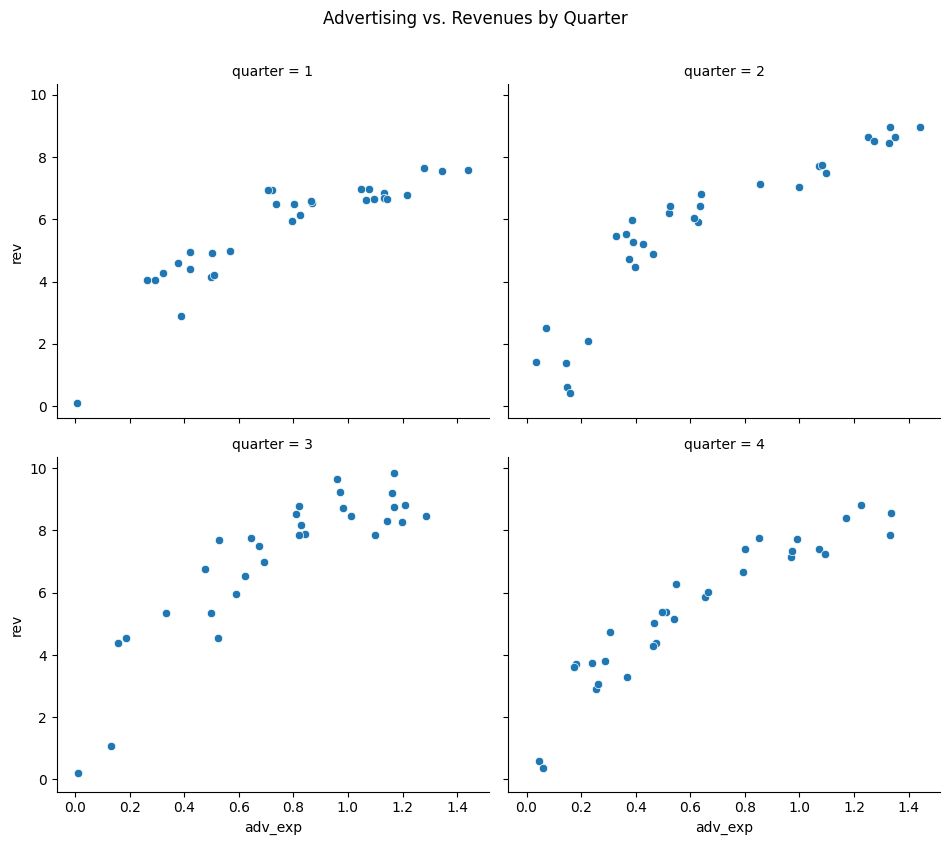

In [7]:
# Create subplots using seaborn's relplot
g = sns.relplot(
    data=df,
    x='adv_exp',
    y='rev',
    col='quarter',
    col_wrap=2,
    kind='scatter',
    height=4,
    aspect=1.2
)
g.fig.suptitle('Advertising vs. Revenues by Quarter', y=1.05)
plt.show()

In [8]:
# C(quarter) tells statsmodels to treat 'quarter' as a categorical dummy variable
model_3 = smf.ols('rev ~ price + adv_exp + C(quarter)', data=df).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                    rev   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     115.4
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           9.62e-44
Time:                        20:04:36   Log-Likelihood:                -166.96
No. Observations:                 124   AIC:                             345.9
Df Residuals:                     118   BIC:                             362.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           6.9365      1.508     

In [9]:
model_mkt = smf.ols('mktshare ~ price + adv_exp + C(quarter)', data=df).fit()
print(model_mkt.summary())

                            OLS Regression Results                            
Dep. Variable:               mktshare   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     131.8
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           1.38e-46
Time:                        20:05:19   Log-Likelihood:                 117.37
No. Observations:                 124   AIC:                            -222.7
Df Residuals:                     118   BIC:                            -205.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.9110      0.152     

Predicted Market Share: 987995.469733604


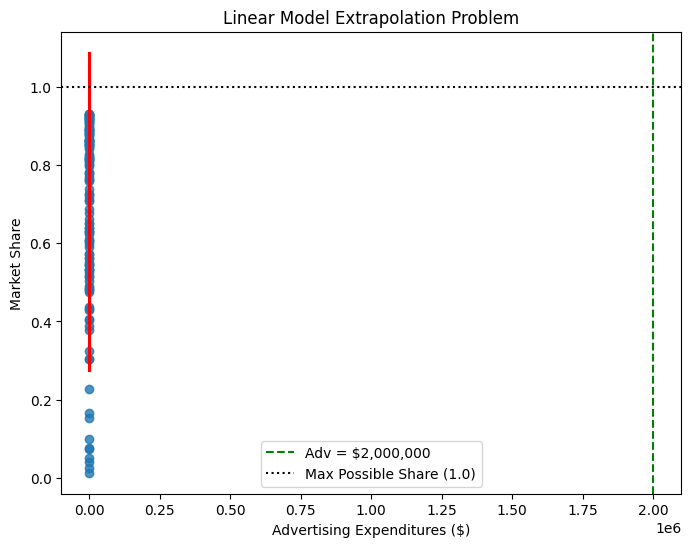

In [10]:
# Create a dataframe for the new prediction point
# Note: Advertising is in raw dollars in the dataset, so 2 million is 2,000,000
new_data = pd.DataFrame({
    'quarter': [1],
    'price': [10],
    'adv_exp': [2000000]
})

predicted_share = model_mkt.predict(new_data)
print(f"Predicted Market Share: {predicted_share.values[0]}")

# Plotting the problem: extending the regression line to extreme values
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='adv_exp', y='mktshare', ci=None, line_kws={"color": "red"})
plt.axvline(x=2000000, color='green', linestyle='--', label='Adv = $2,000,000')
plt.axhline(y=1.0, color='black', linestyle=':', label='Max Possible Share (1.0)')
plt.title('Linear Model Extrapolation Problem')
plt.xlabel('Advertising Expenditures ($)')
plt.ylabel('Market Share')
plt.legend()
plt.show()

In [11]:
# Transform market share using the logit (log-odds) transformation
df['mktshare_logit'] = np.log(df['mktshare'] / (1 - df['mktshare']))

model_alt = smf.ols('mktshare_logit ~ price + adv_exp + C(quarter)', data=df).fit()
print(model_alt.summary())

# To predict and convert back to a 0-1 probability scale for the specific scenario:
predicted_logit = model_alt.predict(new_data)
predicted_share_fixed = 1 / (1 + np.exp(-predicted_logit.values[0]))
print(f"Fixed Predicted Market Share: {predicted_share_fixed}")

                            OLS Regression Results                            
Dep. Variable:         mktshare_logit   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     133.2
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           8.18e-47
Time:                        20:06:39   Log-Likelihood:                -99.654
No. Observations:                 124   AIC:                             211.3
Df Residuals:                     118   BIC:                             228.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.9723      0.877     